In [38]:
## Hippo target selection: AP-1, STAT, and TEA motif filtering

In [39]:
import os, pickle, numpy as np
from collections import Counter

REPO = '/grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra'

# Load the eigen analysis library
with open(os.path.join(REPO, 'genomic_targets', 'data', 'eigen_analysis.pkl'), 'rb') as f:
    cached = pickle.load(f)

print('Keys in pkl:', list(cached.keys()))

Keys in pkl: ['motif_hits', 'eigen_results', 'ei1_vecs', 'ei2_vecs', 'ei1_var', 'ei1_evals', 'ei2_evals', 'ratio', 'corrs', 'has_motifs_both', 'predictions']


In [40]:
motif_hits = cached['motif_hits']   # dict: cell_type -> list of lists (per sequence)
ratio      = cached['ratio']        # EI1/EI2 eigenvalue ratio per sequence
corrs      = cached['corrs']        # importance correlation (r) per sequence
has_motifs_both = cached['has_motifs_both']

n_seqs = len(ratio)
print(f'Total sequences: {n_seqs}')
print(f'With motifs in both cell lines: {has_motifs_both.sum()} ({has_motifs_both.mean():.1%})')

Total sequences: 56975
With motifs in both cell lines: 13561 (23.8%)


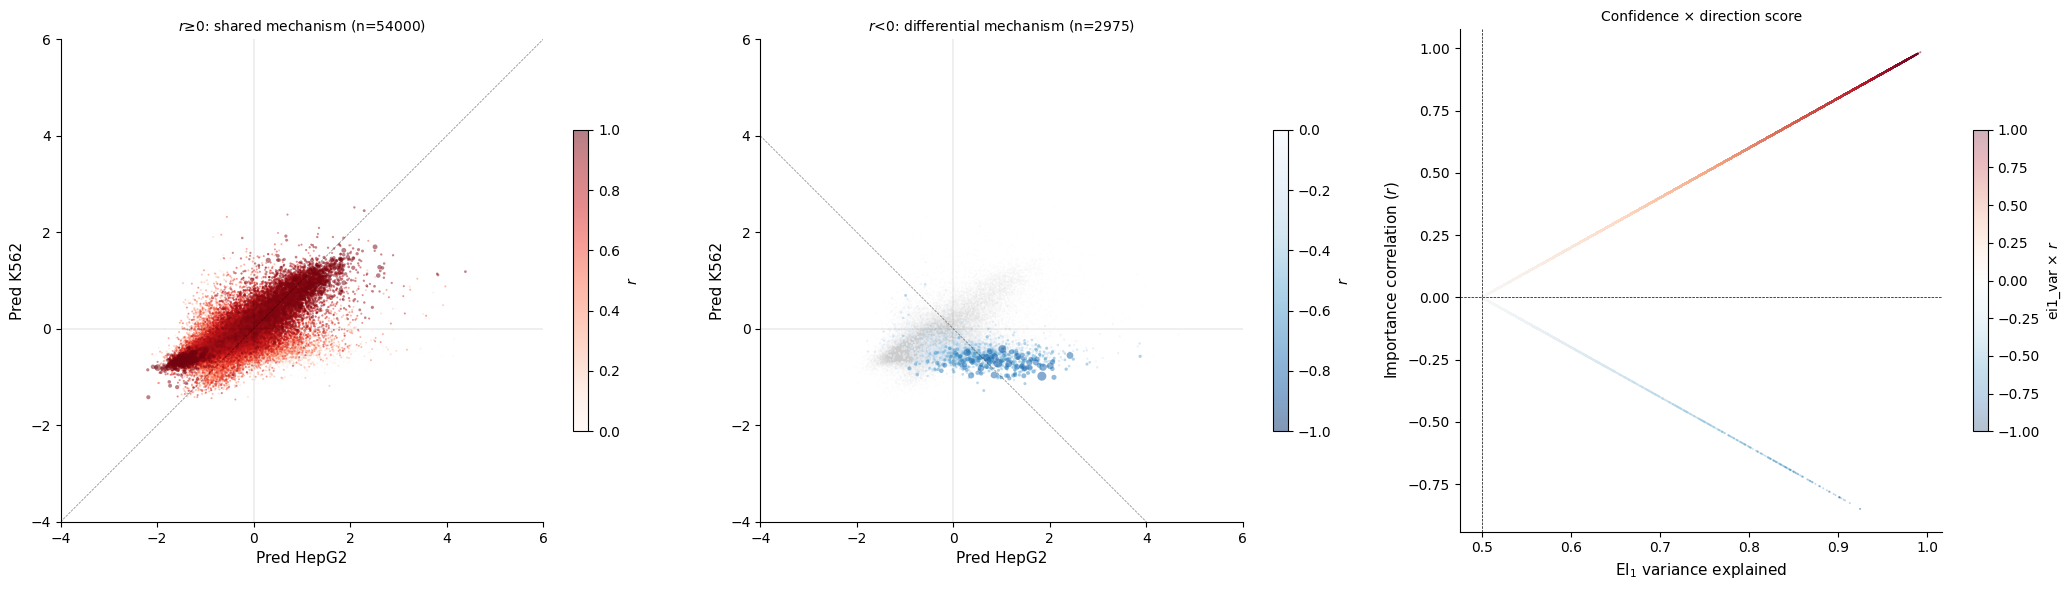

In [41]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

predictions = cached['predictions']
ei1_var = cached['ei1_var']
pos = corrs >= 0
neg = corrs < 0

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))
lims = [-4, 6]

# Left: r>=0, neg grayed
neg_order = np.where(neg)[0][np.argsort(ratio[neg])]
ax1.scatter(predictions['HepG2'][neg_order], predictions['K562'][neg_order],
            s=1, alpha=0.05, c='#cccccc', edgecolors='none', rasterized=True)
pos_order = np.where(pos)[0][np.argsort(np.abs(corrs[pos]))]
pos_sizes = 2 + 40 * (ratio[pos_order] / np.clip(ratio[pos_order].max(), 1, None))**2
sc1 = ax1.scatter(predictions['HepG2'][pos_order], predictions['K562'][pos_order],
                  s=pos_sizes, alpha=0.5, c=corrs[pos_order], cmap='Reds',
                  vmin=0, vmax=1, edgecolors='none', rasterized=True)
ax1.set_title(f'$r$≥0: shared mechanism (n={pos.sum()})', fontsize=10)
plt.colorbar(sc1, ax=ax1, label='$r$', shrink=0.6)
ax1.plot(lims, lims, 'k--', lw=0.5, alpha=0.5)

# Middle: r<0, pos grayed
pos_order2 = np.where(pos)[0][np.argsort(ratio[pos])]
ax2.scatter(predictions['HepG2'][pos_order2], predictions['K562'][pos_order2],
            s=1, alpha=0.05, c='#cccccc', edgecolors='none', rasterized=True)
neg_order = np.where(neg)[0][np.argsort(np.abs(corrs[neg]))]
neg_sizes = 2 + 40 * (ratio[neg_order] / np.clip(ratio[neg_order].max(), 1, None))**2
sc2 = ax2.scatter(predictions['HepG2'][neg_order], predictions['K562'][neg_order],
                  s=neg_sizes, alpha=0.5, c=corrs[neg_order], cmap='Blues_r',
                  vmin=-1, vmax=0, edgecolors='none', rasterized=True)
ax2.set_title(f'$r$<0: differential mechanism (n={neg.sum()})', fontsize=10)
plt.colorbar(sc2, ax=ax2, label='$r$', shrink=0.6)
ax2.plot(lims, [-l for l in lims], 'k--', lw=0.5, alpha=0.5)

for ax in [ax1, ax2]:
    ax.axhline(0, color='k', lw=0.3, alpha=0.3)
    ax.axvline(0, color='k', lw=0.3, alpha=0.3)
    ax.set_xlabel('Pred HepG2', fontsize=11)
    ax.set_ylabel('Pred K562', fontsize=11)
    ax.set_xlim(lims); ax.set_ylim(lims); ax.set_aspect('equal')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Right: ei1_var vs r, colored by score
score = ei1_var * corrs
order = np.argsort(np.abs(score))
sc3 = ax3.scatter(ei1_var[order], corrs[order], s=2, alpha=0.3, c=score[order],
                  cmap='RdBu_r', vmin=-1, vmax=1, edgecolors='none', rasterized=True)
ax3.axhline(0, color='k', lw=0.5, ls='--')
ax3.axvline(0.5, color='k', lw=0.5, ls='--')
ax3.set_xlabel('EI$_1$ variance explained', fontsize=11)
ax3.set_ylabel('Importance correlation ($r$)', fontsize=11)
ax3.set_title('Confidence × direction score', fontsize=10)
plt.colorbar(sc3, ax=ax3, label='ei1_var × $r$', shrink=0.6)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [42]:
score = ei1_var * corrs
hippo_kw = ['TEAD', 'STAT', 'JUN', 'FOS', 'RUNX']

# Per-sequence TF sets (motif syntax = frozenset of TFs)
seq_tf_sets = []
for i in range(n_seqs):
    tfs_i = set()
    for ct in ['K562', 'HepG2']:
        for h in motif_hits[ct][i]:
            for alt in h.get('top_hits', []):
                tfs_i.add(alt['tf'])
    seq_tf_sets.append(frozenset(tfs_i))

# Group sequences by their motif syntax
from collections import defaultdict
syntax_seqs = defaultdict(list)
for i in range(n_seqs):
    if seq_tf_sets[i]:  # skip empty
        syntax_seqs[seq_tf_sets[i]].append(i)

# For each syntax: mean score, count, and fraction same-diff
syntaxes, mean_scores, n_seqs_list, frac_sd = [], [], [], []
for syntax, idxs in syntax_seqs.items():
    if len(idxs) < 3:
        continue
    s = score[idxs]
    syntaxes.append(syntax)
    mean_scores.append(np.mean(s))
    n_seqs_list.append(len(idxs))
    frac_sd.append((s < 0).mean())

mean_scores = np.array(mean_scores)
n_seqs_list = np.array(n_seqs_list)
frac_sd = np.array(frac_sd)

# Top same-diff syntaxes (candidates for perturbation)
sd_order = np.argsort(mean_scores)

print('Top 20 same-diff motif syntaxes (lowest score):')
for j in sd_order[:20]:
    tfs_str = ', '.join(sorted(syntaxes[j]))
    has_hippo = any(any(k in tf.upper() for k in hippo_kw) for tf in syntaxes[j])
    marker = ' ** HIPPO' if has_hippo else ''
    print(f'  score={mean_scores[j]:+.3f}  n={n_seqs_list[j]:3d}  frac_sd={frac_sd[j]:.0%}  [{tfs_str}]{marker}')

print(f'\nTop 20 same-same motif syntaxes (highest score):')
for j in sd_order[-20:][::-1]:
    tfs_str = ', '.join(sorted(syntaxes[j]))
    has_hippo = any(any(k in tf.upper() for k in hippo_kw) for tf in syntaxes[j])
    marker = ' ** HIPPO' if has_hippo else ''
    print(f'  score={mean_scores[j]:+.3f}  n={n_seqs_list[j]:3d}  frac_sd={frac_sd[j]:.0%}  [{tfs_str}]{marker}')

# Build focus_tfs from top same-diff syntaxes containing hippo TFs
focus_tfs = set()
hippo_tfs = set()
for j in sd_order[:50]:
    for tf in syntaxes[j]:
        focus_tfs.add(tf)
        if any(k in tf.upper() for k in hippo_kw):
            hippo_tfs.add(tf)
# Also add top same-same
for j in sd_order[-50:]:
    for tf in syntaxes[j]:
        focus_tfs.add(tf)
        if any(k in tf.upper() for k in hippo_kw):
            hippo_tfs.add(tf)

sig_tfs = focus_tfs - hippo_tfs
print(f'\nFocus TFs from top syntaxes: {len(focus_tfs)}')
print(f'  Hippo: {sorted(hippo_tfs)}')
print(f'  Other: {sorted(sig_tfs)}')

Top 20 same-diff motif syntaxes (lowest score):
  score=-0.702  n=  3  frac_sd=100%  [HNF1A, HNF1B, POU6F1, ZBTB47]
  score=-0.520  n=  3  frac_sd=100%  [HNF1A, HNF1B, POU4F2, RXRB, RXRG, Rxra]
  score=-0.480  n= 10  frac_sd=100%  [HNF1A, HNF1B, POU6F1, RXRB, RXRG, Rxra]
  score=-0.440  n=  6  frac_sd=100%  [ATF6, CREB3L1, HNF1A, HNF1B, RXRB, RXRG, Rxra, XBP1, ZBTB47]
  score=-0.420  n=  3  frac_sd=100%  [HNF1A, HNF1B, LHX2]
  score=-0.419  n= 22  frac_sd=100%  [HNF1A, HNF1B, mix-a]
  score=-0.409  n=  4  frac_sd=100%  [HNF1A, HNF1B, PKNOX2, POU6F1, SNAI2, ZEB1]
  score=-0.335  n= 12  frac_sd=92%  [HNF1A, HNF1B, POU4F2]
  score=-0.330  n= 11  frac_sd=100%  [GSC::TBX21, HNF1A, HNF1B]
  score=-0.322  n=  4  frac_sd=100%  [ATF6, CREB3L1, HNF1A, HNF1B, PKNOX2, POU6F1, SNAI2, XBP1, ZEB1]
  score=-0.297  n=  6  frac_sd=100%  [HNF1A, HNF1B, ZSCAN16]
  score=-0.295  n=  8  frac_sd=100%  [ATF6, CREB3L1, HNF1A, HNF1B, POU6F1, RXRB, RXRG, Rxra, XBP1]
  score=-0.290  n= 12  frac_sd=92%  [HNF1A, HN

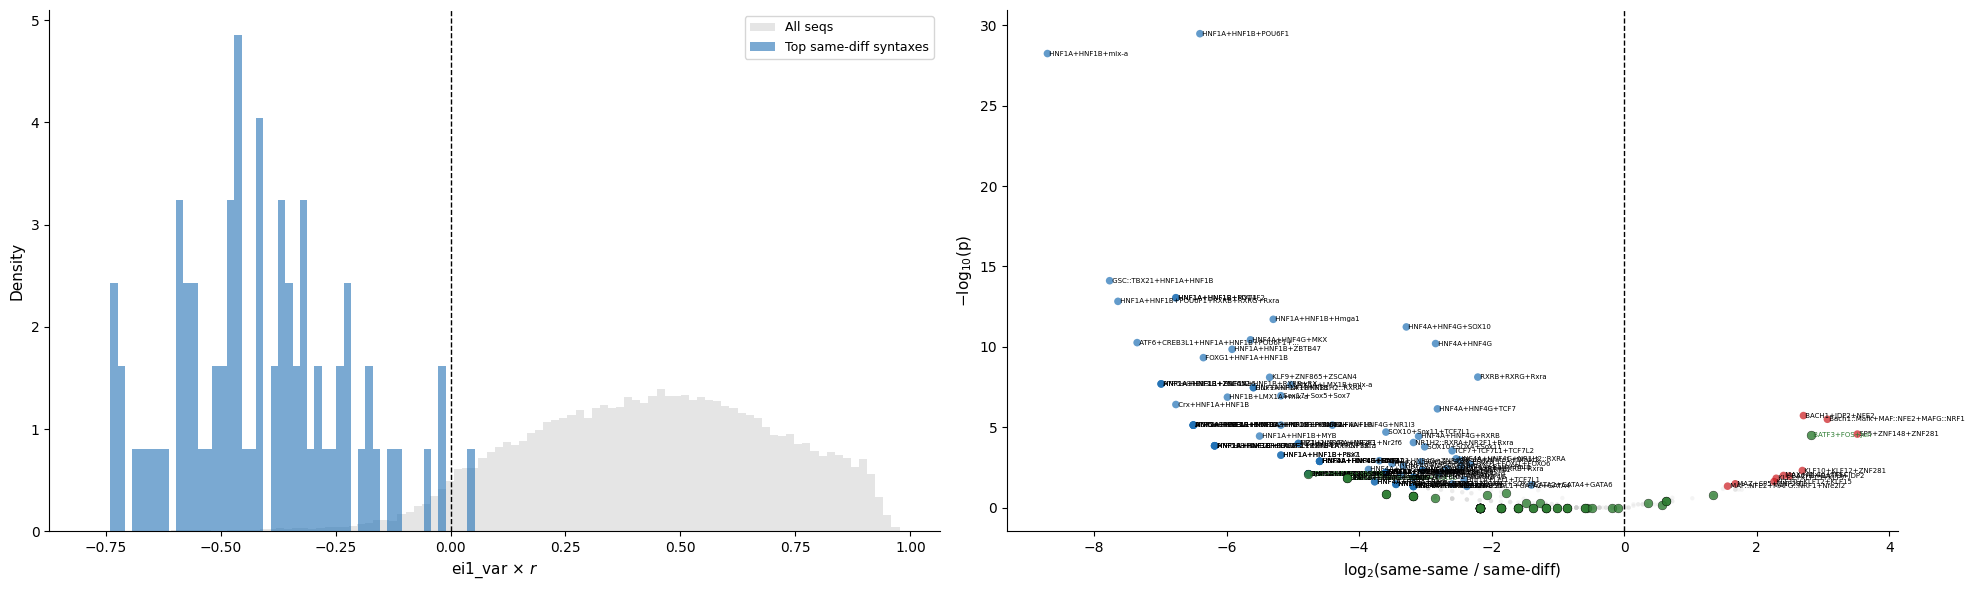

Significant syntaxes (p<0.05): 117

Top 10 same-diff syntaxes:
  score=-0.702  n=  3  [HNF1A, HNF1B, POU6F1, ZBTB47]
  score=-0.520  n=  3  [HNF1A, HNF1B, POU4F2, RXRB, RXRG, Rxra]
  score=-0.480  n= 10  [HNF1A, HNF1B, POU6F1, RXRB, RXRG, Rxra]
  score=-0.440  n=  6  [ATF6, CREB3L1, HNF1A, HNF1B, RXRB, RXRG, Rxra, XBP1, ZBTB47]
  score=-0.420  n=  3  [HNF1A, HNF1B, LHX2]
  score=-0.419  n= 22  [HNF1A, HNF1B, mix-a]
  score=-0.409  n=  4  [HNF1A, HNF1B, PKNOX2, POU6F1, SNAI2, ZEB1]
  score=-0.335  n= 12  [HNF1A, HNF1B, POU4F2]
  score=-0.330  n= 11  [GSC::TBX21, HNF1A, HNF1B]
  score=-0.322  n=  4  [ATF6, CREB3L1, HNF1A, HNF1B, PKNOX2, POU6F1, SNAI2, XBP1, ZEB1]


In [43]:
from scipy.stats import fisher_exact

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Left: score distribution
ax1.hist(score, bins=100, density=True, color='#cccccc', alpha=0.5, label='All seqs')
sd_idxs = []
for j in sd_order[:10]:
    sd_idxs.extend(syntax_seqs[syntaxes[j]])
sd_idxs = np.array(sd_idxs)
ax1.hist(score[sd_idxs], bins=50, density=True, alpha=0.6, color='#2171b5', label='Top same-diff syntaxes')
ax1.axvline(0, color='k', lw=1, ls='--')
ax1.set_xlabel('ei1_var × $r$', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.legend(fontsize=9)
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Right: volcano — each dot = a motif syntax
n_total_ss = (score > 0).sum()
n_total_sd = (score < 0).sum()

vlfc, vnlp, vhippo, vsyntax_idx = [], [], [], []
for j in range(len(syntaxes)):
    idxs = syntax_seqs[syntaxes[j]]
    a = sum(1 for i in idxs if score[i] > 0)
    b = sum(1 for i in idxs if score[i] < 0)
    if a + b < 3:
        continue
    lfc = np.log2(((a+1)/(n_total_ss+1)) / ((b+1)/(n_total_sd+1)))
    _, pval = fisher_exact([[a, n_total_ss - a], [b, n_total_sd - b]])
    pval = max(pval, 1e-300)
    vlfc.append(lfc); vnlp.append(-np.log10(pval))
    vhippo.append(any(any(k in tf.upper() for k in hippo_kw) for tf in syntaxes[j]))
    vsyntax_idx.append(j)

vlfc, vnlp, vhippo = np.array(vlfc), np.array(vnlp), np.array(vhippo)
vsig = vnlp > -np.log10(0.05)

ax2.scatter(vlfc[~vsig & ~vhippo], vnlp[~vsig & ~vhippo], s=10, alpha=0.2, c='#cccccc', edgecolors='none')
sig_colors = ['#cb181d' if l > 0 else '#2171b5' for l in vlfc[vsig & ~vhippo]]
ax2.scatter(vlfc[vsig & ~vhippo], vnlp[vsig & ~vhippo], s=30, alpha=0.7, c=sig_colors, edgecolors='none')
ax2.scatter(vlfc[vhippo], vnlp[vhippo], s=40, alpha=0.8, c='#2E7D32', edgecolors='k', lw=0.3, zorder=5)

for i in np.where(vsig)[0]:
    j = vsyntax_idx[i]
    label = '+'.join(sorted(syntaxes[j]))
    if len(label) > 35:
        label = label[:32] + '...'
    c = '#2E7D32' if vhippo[i] else 'black'
    ax2.text(vlfc[i], vnlp[i], ' ' + label, fontsize=5, va='center', color=c)

ax2.axvline(0, color='k', lw=1, ls='--')
ax2.set_xlabel('log$_2$(same-same / same-diff)', fontsize=11)
ax2.set_ylabel('$-$log$_{10}$(p)', fontsize=11)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Significant syntaxes (p<0.05): {vsig.sum()}')
print('\nTop 10 same-diff syntaxes:')
for j in sd_order[:10]:
    tfs_str = ', '.join(sorted(syntaxes[j]))
    has_h = any(any(k in tf.upper() for k in hippo_kw) for tf in syntaxes[j])
    print(f'  score={mean_scores[j]:+.3f}  n={n_seqs_list[j]:3d}  [{tfs_str}]{"  ** HIPPO" if has_h else ""}')

  K562: 58721 genes, median TPM=0.00
  HepG2: 58721 genes, median TPM=0.00


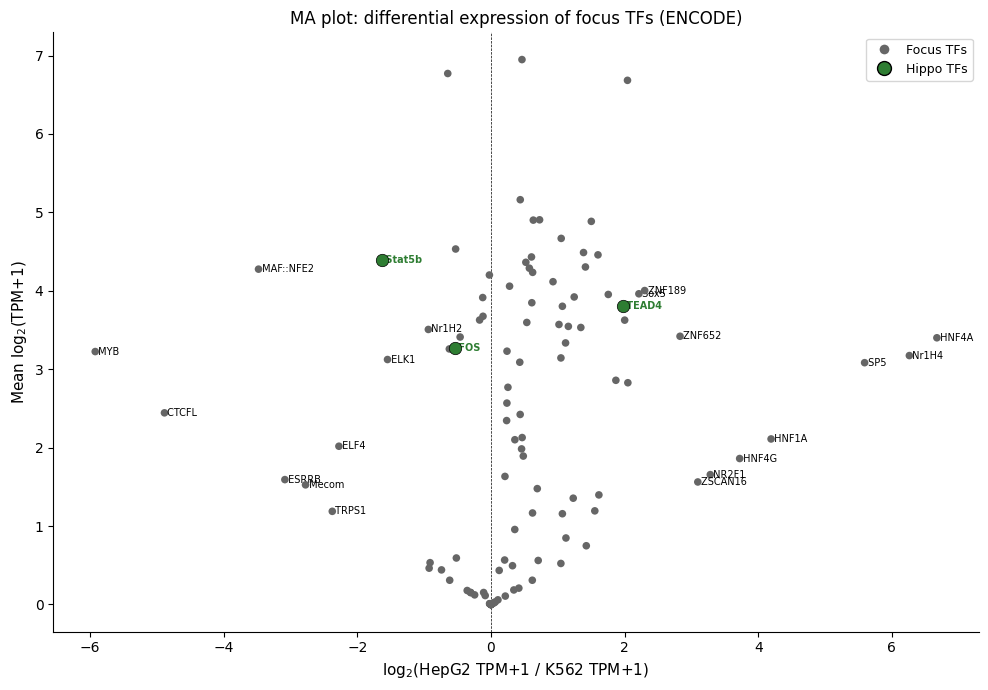

In [44]:
import sys
sys.path.insert(0, os.path.join(REPO, 'eigen-interactions'))
from eigen_steering import load_encode_expression

expr = load_encode_expression(['K562', 'HepG2'])
tf_tpm = {}
for ct, edf in expr.items():
    for _, row in edf.iterrows():
        tf_tpm.setdefault(row['gene_name'].upper(), {})[ct] = row['TPM']

def get_tpm(tf_name, ct):
    parts = tf_name.replace('::', ':').split(':')
    tpms = [tf_tpm.get(p.strip().upper(), {}).get(ct, 0) for p in parts]
    return max(tpms) if tpms else 0

# Show all focus TFs on MA plot
show_tfs_list = sorted(focus_tfs)
is_hippo_show = np.array([any(k in tf.upper() for k in hippo_kw) for tf in show_tfs_list])

tpm_h = np.array([get_tpm(tf, 'HepG2') for tf in show_tfs_list])
tpm_k = np.array([get_tpm(tf, 'K562') for tf in show_tfs_list])
expr_lfc = np.log2((tpm_h + 1) / (tpm_k + 1))
mean_expr = (np.log2(tpm_h + 1) + np.log2(tpm_k + 1)) / 2

# Label: hippo TFs + top 10 most HepG2-enriched + top 10 most K562-enriched
lfc_order = np.argsort(expr_lfc)
label_idx = set(np.where(is_hippo_show)[0])
label_idx.update(lfc_order[:10])   # most K562
label_idx.update(lfc_order[-10:])  # most HepG2

fig, ax = plt.subplots(figsize=(10, 7))
from matplotlib.lines import Line2D

for i, tf in enumerate(show_tfs_list):
    if is_hippo_show[i]:
        c, s, z = '#2E7D32', 80, 5
    else:
        c, s, z = '#666666', 30, 3
    ax.scatter(expr_lfc[i], mean_expr[i], s=s, c=c,
               edgecolors='k' if is_hippo_show[i] else 'none', lw=0.5, zorder=z)
    if i in label_idx:
        ax.text(expr_lfc[i], mean_expr[i], ' ' + tf, fontsize=7, va='center',
                fontweight='bold' if is_hippo_show[i] else 'normal',
                color='#2E7D32' if is_hippo_show[i] else 'black')

ax.axvline(0, color='k', lw=0.5, ls='--')
ax.set_xlabel('log$_2$(HepG2 TPM+1 / K562 TPM+1)', fontsize=11)
ax.set_ylabel('Mean log$_2$(TPM+1)', fontsize=11)
ax.set_title('MA plot: differential expression of focus TFs (ENCODE)')
ax.legend(handles=[
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#666666', markersize=8, label='Focus TFs'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2E7D32', markeredgecolor='k', markersize=10, label='Hippo TFs'),
], fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [45]:
import pandas as pd

df = pd.read_csv(os.path.join(REPO, 'data', 'joint_library_combined.csv'))
CT = {'K562': 'K562_v6_do075', 'HepG2': 'HepG2_v6_do03'}
df = df.dropna(subset=['sequence'] + [f'{ct}_log2FC' for ct in CT]).reset_index(drop=True)

# focus_tfs, hippo_tfs, sig_tfs already set by syntax analysis cell

# All sequences with any focus TF — ranked by |score|, no threshold
records = []
for i in range(n_seqs):
    matching = seq_tf_sets[i] & focus_tfs
    if not matching:
        continue
    records.append({
        'idx': i,
        'score': score[i],
        'ei1_var': ei1_var[i],
        'ratio': ratio[i],
        'corr': corrs[i],
        'pred_HepG2': predictions['HepG2'][i],
        'pred_K562': predictions['K562'][i],
        'matching_tfs': ','.join(sorted(matching)),
        'all_tfs': ','.join(sorted(seq_tf_sets[i])),
    })

focused = pd.DataFrame(records).sort_values('score', key=abs, ascending=False)
focused = focused.merge(df[['sequence', 'name'] + [f'{ct}_log2FC' for ct in CT]],
                        left_on='idx', right_index=True)

print(f'Focused library: {len(focused)} sequences (ranked by |score|, no threshold)')
print(f'  score > 0 (same-same): {(focused.score > 0).sum()}')
print(f'  score < 0 (same-diff): {(focused.score < 0).sum()}')
print(f'\nFocus TFs ({len(focus_tfs)}):')
print(f'  Hippo: {sorted(hippo_tfs)}')
print(f'  Other: {sorted(sig_tfs)}')
print(f'\nTop 10 same-same (highest score):')
print(focused[focused.score > 0][['score', 'ei1_var', 'corr', 'matching_tfs']].head(10).to_string())
print(f'\nTop 10 same-diff (most negative score):')
print(focused[focused.score < 0].sort_values('score')[['score', 'ei1_var', 'corr', 'matching_tfs']].head(10).to_string())

Focused library: 25626 sequences (ranked by |score|, no threshold)
  score > 0 (same-same): 23386
  score < 0 (same-diff): 2240

Focus TFs (130):
  Hippo: ['FOS', 'Stat5b', 'TEAD4']
  Other: ['ATF6', 'Ahr::Arnt', 'Arid3a', 'BARHL1', 'BCL11A', 'BHLHE22', 'Bach1::Mafk', 'Banp', 'CREB3L1', 'CTCFL', 'Crx', 'DUX4', 'Dmrt1', 'Dux', 'ELF1', 'ELF4', 'ELK1', 'ELK3', 'ESRRA', 'ESRRB', 'Erg', 'FIZ1', 'FOXG1', 'GATA6', 'GSC::TBX21', 'HMBOX1', 'HNF1A', 'HNF1B', 'HNF4A', 'HNF4G', 'Hmga1', 'IKZF2', 'Ikzf3', 'KLF10', 'KLF4', 'KLF8', 'KLF9', 'LHX2', 'LMX1A', 'MAF::NFE2', 'MAFF', 'MAFG::NRF1', 'MAZ', 'MKX', 'MYB', 'MYT1', 'Mecom', 'NFIA', 'NFYA', 'NFYB', 'NFYC', 'NR1H2::RXRA', 'NR2F1', 'NR4A1', 'NRL', 'Neurod2', 'Nr1H2', 'Nr1H4', 'Nr2f6', 'Nr5a2', 'OSR1', 'PAX3', 'PBX1', 'PKNOX2', 'POU4F2', 'POU6F1', 'Pax7', 'RBPJ', 'REST', 'RXRB', 'RXRG', 'Rarb', 'Rxra', 'SATB1', 'SCAND3', 'SNAI2', 'SOX10', 'SP1', 'SP4', 'SP5', 'SREBF2', 'Sox11', 'Sox17', 'Sox5', 'Sox7', 'TFAP4::FLI1', 'TRPS1', 'Thap11', 'Twist2', 'VEZ

In [46]:
save_path = os.path.join(REPO, 'genomic_targets', 'library', 'hippo_focused_library.pkl')

idxs = focused.idx.values
focused_motif_hits = {
    ct: [motif_hits[ct][i] for i in idxs]
    for ct in ['K562', 'HepG2']
}
focused_eigen = [cached['eigen_results'][i] for i in idxs]

save_data = {
    'df': focused,                       # ranked by |score|, includes score, ei1_var, ratio, corr
    'motif_hits': focused_motif_hits,     # {ct: list of lists} with start, end, tf, pval, top_hits
    'eigen_results': focused_eigen,       # per-seq eigenvectors, eigenvalues, cov, var_ratio
    'focus_tfs': sorted(focus_tfs),
    'hippo_tfs': sorted(hippo_tfs),
    'sig_tfs': sorted(sig_tfs),
    'attr_npz_path': os.path.join(REPO, 'genomic_targets', 'data', 'deeplift_attributions.npz'),
}

with open(save_path, 'wb') as f:
    pickle.dump(save_data, f)

print(f'Saved to {save_path}')
print(f'  {len(focused)} sequences, ranked by |ei1_var × r|')
print(f'  Keys: {list(save_data.keys())}')
print(f'  Attribution maps: index into npz with df.idx')

Saved to /grid/wsbs/home_norepl/pmantill/Virtual_Experiments/Hippo_axis/Hippo_dependency_mpra/genomic_targets/library/hippo_focused_library.pkl
  25626 sequences, ranked by |ei1_var × r|
  Keys: ['df', 'motif_hits', 'eigen_results', 'focus_tfs', 'hippo_tfs', 'sig_tfs', 'attr_npz_path']
  Attribution maps: index into npz with df.idx
